# Feather River Watershed: Seasonal Precipitation Changes

The Feather River is CA's most significant (in terms of receiving the most rain) our of any of its watershed! It feeds Lake Oroville, one of the largest reservoirs in California. If seasonal precipitation shifts up in the watershed, everything downstream shifts with it — flood-control releases and summer supply.

So: what does LOCA2 say about the seasonal cycle at the watershed's upper end?

We'll use the library functions to go though, leveraging,  probing helpers (`CatalogExplorer`, `what_is_available`) to confirm what data exists for the region *before* fetching, then uses xarray's native season handling for meteorologically correct DJF/MAM/JJA/SON aggregation, and then use the coiled helper functions to get the data quickly! Analysis windows follow IPCC AR6 conventions.

### Method summary

| | |
|---|---|
| **Reference period** | 1985-2014 (30-year normal within LOCA2 historical) |
| **Future window** | 2041-2060 (IPCC AR6 "mid-term") |
| **Scenarios** | Historical + SSP 2-4.5, SSP 3-7.0, SSP 5-8.5 |
| **Ensemble** | 15 LOCA2 GCMs (multi-model ensemble mean + 10-90 percentile spread) |
| **Seasons** | Meteorological: DJF / MAM / JJA / SON (xarray native) |
| **% change convention** | (MMEM_future − MMEM_hist) / MMEM_hist, per IPCC AR6 |

In [1]:
import sys, os
import coiled
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "lib"))

from andrewAdaptLibrary import (
    CatalogExplorer,          # probing: what exists in the live catalog
    ParkCatalog,              # probing: geographic search + per-park data availability
    get_climate_data,         # parallel fetch via Coiled
    annual_aggregate,         # lib helper: monthly -> annual (Precip sum, Temperature mean)
    smooth,                   # lib helper: centered rolling mean
)

NPS_SHP = os.path.join(
    PROJECT_ROOT,
    "USA_National_Park_Service_Lands_20170930_4993375350946852027",
    "USA_Federal_Lands.shp",
)
park_catalog = ParkCatalog(NPS_SHP)
print(park_catalog)

/opt/conda/envs/py-env/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: /workspaces/DSEBrandNew/USA_National_Park_Service_Lands_20170930_4993375350946852027/USA_Federal_Lands.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


ParkCatalog(437 NPS units)


## 1. Probe the catalog — what does Cal-Adapt actually have at monthly resolution?

`CatalogExplorer` reads the live Cal-Adapt catalog CSV from S3 — no hardcoded assumptions about what variables or scenarios exist. This is the first sanity check before any analysis.

In [2]:
cat = CatalogExplorer(timescale="monthly")
print(cat)
print(f"\nVariables ({len(cat.variables())}):")
for vid, name in cat.variables().items():
    print(f"  {vid:10s} → {name}")

print(f"\nScenarios:")
for eid, name in cat.scenarios().items():
    print(f"  {eid:12s} → {name}")

CatalogExplorer(activity='LOCA2', timescale='monthly', grid='d03', stores=1585)

Variables (10):
  hursmax    → RH_Max
  hursmin    → RH_Min
  huss       → SpecHum
  pr         → Precip
  rsds       → SW_Down
  tasmax     → T_Max
  tasmin     → T_Min
  uas        → Wind_U
  vas        → Wind_V
  wspeed     → WSpeed

Scenarios:
  historical   → Historical Climate
  ssp245       → SSP 2-4.5
  ssp370       → SSP 3-7.0
  ssp585       → SSP 5-8.5


In [3]:
# Cross-tab: how many GCM simulations exist per (variable × scenario)?
# This is the "ensemble size" dimension we'll rely on later for uncertainty.
cat.summary()

experiment_id,historical,ssp245,ssp370,ssp585
variable_id,,,,
hursmax,51,25,45,25
hursmin,51,25,45,25
huss,48,24,45,22
pr,70,33,62,34
rsds,51,30,45,29
tasmax,70,33,62,34
tasmin,70,33,62,34
uas,46,24,38,26
vas,46,24,38,26


In [4]:
# Precipitation specifically — how many models, and what's the actual time range?
gcms_hist = cat.gcms(variable_id="pr", experiment_id="historical")
print(f"GCMs with historical pr: {len(gcms_hist)}")
print(f"First few: {gcms_hist[:5]}")

# Probe actual time bounds by opening a Zarr store
hist_range = cat.time_range("pr", "historical")
future_range = cat.time_range("pr", "ssp245")
print(f"\nHistorical Precip: {hist_range[0]}-{hist_range[1]}")
print(f"SSP 2-4.5 Precip:  {future_range[0]}-{future_range[1]}")

GCMs with historical pr: 15
First few: ['ACCESS-CM2', 'CESM2-LENS', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg']

Historical Precip: 1950-2014
SSP 2-4.5 Precip:  2015-2100


## 2. Find the target park — search the mega NPS layer

Feather River itself isn't an NPS unit, so the obvious query comes up empty:

In [5]:
park_catalog.search("feather river", top_n=5)

search: "feather river"
   59.5  Chattahoochee River National Recreation Area  *
   59.5  Little River Canyon National Preserve  *
   59.5  Middle Delaware National Scenic River  *
   59.5  New River Gorge National Park and Preserve  *
   59.5  Salt River Bay National Historical Park and Ecological Preserve  *


[('Chattahoochee River National Recreation Area', 59.49999999999999),
 ('Little River Canyon National Preserve', 59.49999999999999),
 ('Middle Delaware National Scenic River', 59.49999999999999),
 ('New River Gorge National Park and Preserve', 59.49999999999999),
 ('Salt River Bay National Historical Park and Ecological Preserve',
  59.49999999999999)]

Scores in the 50s-60s across totally-wrong-coast rivers — no meaningful match. Fall back to geography: the North Fork Feather rises on the southern flanks of the Lassen volcanic dome, so the NPS unit there is our proxy.

In [6]:
park_catalog.search("lassen", top_n=3)

search: "lassen"
   92.1  Lassen Volcanic National Park  *
   52.3  Ulysses S. Grant National Historic Site
   51.0  Bering Land Bridge National Preserve


[('Lassen Volcanic National Park', 92.06896551724138),
 ('Ulysses S. Grant National Historic Site', 52.307692307692314),
 ('Bering Land Bridge National Preserve', 51.0)]

## 3. Probe the park — does Cal-Adapt have data here?

`what_is_available()` actually opens Zarr stores and checks what exists at this park's coordinates. For parks inside the LOCA2 grid (western US) it's a fast hardcoded path; for parks outside, it probes WRF stores live.

In [7]:
park_catalog.what_is_available("Lassen Volcanic National Park")

Lassen Volcanic National Park
  lat 40.34 to 40.59, lon -121.62 to -121.25
  inside LOCA2 grid -- all western US data available

  LOCA2 3km (statistical)
    scenarios:  historical, ssp245, ssp370, ssp585
    timescales: monthly, daily, yearly
    variables:  10
    models:     15
  WRF 3km (dynamical)
    scenarios:  historical, reanalysis, ssp370
    timescales: hourly, daily, monthly
    variables:  57
    models:     9
  WRF 9km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9
  WRF 45km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9



{'LOCA2_d03': {'name': 'LOCA2 3km (statistical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['monthly', 'daily', 'yearly'],
  'n_variables': 10,
  'variables': ['tasmax',
   'tasmin',
   'pr',
   'hursmax',
   'hursmin',
   'huss',
   'rsds',
   'uas',
   'vas',
   'wspeed'],
  'n_models': 15},
 'WRF_d03': {'name': 'WRF 3km (dynamical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'reanalysis', 'ssp370'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 57,
  'n_models': 9},
 'WRF_d02': {'name': 'WRF 9km (dynamical)',
  'resolution': '9 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 54,
  'n_models': 9},
 'WRF_d01': {'name': 'WRF 45km (dynamical)',
  'resolution': '45 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variabl

Lassen is inside the LOCA2 3km grid — full scenario/variable/timescale coverage, 15 GCMs. Proceed.

Load the boundary GeoDataFrame (dissolved multi-polygons, EPSG:4326 — ready to hand straight to `get_climate_data`):

bounds (lon/lat): [-121.62008561   40.34450618 -121.24678171   40.58502299]
area:             435 km²


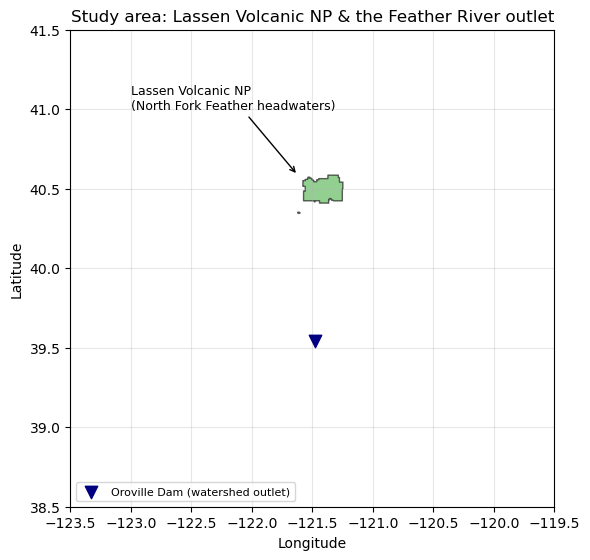

In [8]:
lassen = park_catalog.get_boundary("Lassen Volcanic National Park")
print(f"bounds (lon/lat): {lassen.total_bounds}")
print(f"area:             {lassen.to_crs('EPSG:3310').area.iloc[0] / 1e6:.0f} km²")

# Quick orientation plot: park outline on a regional map
fig, ax = plt.subplots(figsize=(6, 6))
lassen.plot(ax=ax, facecolor="#4daf4a", edgecolor="black", alpha=0.6)
ax.scatter([-121.48], [39.54], marker="v", s=80, color="navy", zorder=5,
           label="Oroville Dam (watershed outlet)")
ax.annotate("Lassen Volcanic NP\n(North Fork Feather headwaters)",
            xy=lassen.total_bounds[[0, 3]], xytext=(-123, 41),
            fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_xlim(-123.5, -119.5)
ax.set_ylim(38.5, 41.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Study area: Lassen Volcanic NP & the Feather River outlet")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()

## 4. Spin up a Coiled cluster

Small cluster — 4 workers, same config as the spatial-comparison notebook. One park × one variable × four scenarios is a light workload.

In [9]:
cluster = coiled.Cluster(
    name="feather-river-precip",
    region="us-west1",
    n_workers=4,
    worker_memory="8 GiB",
    spot_policy="spot_with_fallback",
    idle_timeout="15 minutes",
    package_sync=True,
)
client = cluster.get_client()
print(f"Workers: {len(client.scheduler_info()['workers'])}")

/tmp/ipykernel_71113/1215725867.py:1: FutureWarning: `package_sync` is a deprecated kwarg for `Cluster` and will be removed in a future release. To only sync certain packages, use `package_sync_only`, and to disable package sync, pass the `container` or `software` kwargs instead.
  cluster = coiled.Cluster(


Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_lib │ Source wheel built from /workspaces/DSEBrandNew/lib     │
│   climakitae       │ Wheel built from                                        │
│                    │ https://github.com/cal-adapt/climakitae/archive/refs/   │
│                    │ tags/1.4.0.zip                                          │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│             ╷                                                    ╷           │
│   Package   │ Error                                              │ Level     │
│ ╶───────────┼────────────────────────────────────────────────────┼─────────╴ │
│   shiboken6 │ cannot find shiboken6~=6.10.2 on pypi.org. If you  │ Warning   │
│             │ are using a custom PyPI URL, please see            │           │
│             │ https://docs.coiled.io/user_guide/software/packag… │           │
│             │ for more instructions.                             │           │
│             ╵                                                    ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

Workers: 0


## 5. Fetch monthly precipitation across all scenarios

`get_climate_data` dispatches one Dask task per (variable × scenario); workers in us-west-2 read the Zarr stores directly, do unit conversion and cosine-latitude-weighted spatial averaging over the park boundary, and return a tidy DataFrame.

In [10]:
scenarios = ["Historical Climate", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]

data = get_climate_data(
    variables=["Precip"],
    scenarios=scenarios,
    boundary=lassen,
    time_slice=(1950, 2100),
    timescale="monthly",
    backend="coiled",
    coiled_cluster=cluster,
)
df = data["Precip"]
print(f"rows: {len(df):,}")
print(f"cols: {list(df.columns)}")
print(f"unique simulations: {df['simulation'].nunique()}")
print(f"time range: {df['time'].min()} → {df['time'].max()}")

rows: 187,728
cols: ['simulation', 'time', 'spatial_ref', 'Precip', 'scenario', 'timescale']
unique simulations: 70
time range: 1950-01-01 00:00:00 → 2100-12-01 00:00:00


## 6. Reshape to xarray for climatological operations

The fetched DataFrame is tidy but the analysis we want (meteorological seasons, ensemble stats, climatologies) is much cleaner in xarray. One reshape, then everything downstream is xarray-idiomatic.

In [11]:
# Build a single DataArray with dims (scenario, simulation, time)
df["time"] = pd.to_datetime(df["time"])
precip = (
    df.set_index(["scenario", "simulation", "time"])["Precip"]
      .to_xarray()
      .sortby("time")
)
precip.attrs["units"] = "mm/month"
precip.attrs["long_name"] = "Monthly total precipitation"
precip

<xarray.DataArray 'Precip' (scenario: 4, simulation: 70, time: 1812)> Size: 4MB
array([[[2.65538058e+02, 1.51375824e+02, 2.83264250e+02, ...,
                    nan,            nan,            nan],
        [4.09537956e+02, 2.27339460e+02, 9.85070388e+01, ...,
                    nan,            nan,            nan],
        [6.34207025e+02, 5.87828691e+01, 1.02418685e+02, ...,
                    nan,            nan,            nan],
        ...,
        [5.56618773e+01, 4.23463845e+02, 1.04118577e+02, ...,
                    nan,            nan,            nan],
        [3.25803982e+02, 6.55687208e-02, 1.42818252e+02, ...,
                    nan,            nan,            nan],
        [2.52365460e+02, 9.58104648e+01, 2.30724722e+02, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
         1.42571576e+02, 1.08701685e+02, 6.13557755e+02],
        [           nan,            nan,            nan, ...,
         6.33003877e+01, 3.77589905e+02, 1.97991213e+02],
        [           nan,            nan,            nan, ...,
         4.63619633e+01, 4.92780128e+01, 7.75500346e+01],
...
         2.50814862e+01, 2.96022615e+02, 1.77666295e+02],
        [           nan,            nan,            nan, ...,
         6.58610426e+01, 2.44341154e+02, 1.93243674e+02],
        [           nan,            nan,            nan, ...,
         3.32191941e+01, 3.00613901e+02, 7.01976589e+02]],

       [[           nan,            nan,            nan, ...,
         2.05159222e+01, 1.80015892e+02, 1.87898651e+02],
        [           nan,            nan,            nan, ...,
         6.43139764e+01, 5.28992529e+02, 4.39396586e+01],
        [           nan,            nan,            nan, ...,
         8.78933488e+01, 5.97231674e+01, 4.37838781e+00],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(4, 70, 1812))
Coordinates:
  * scenario    (scenario) object 32B 'Historical Climate' ... 'SSP 5-8.5'
  * simulation  (simulation) object 560B 'LOCA2_ACCESS-CM2_r1i1p1f1' ... 'LOC...
  * time        (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2100-12-01
Attributes:
    units:      mm/month
    long_name:  Monthly total precipitation

## 7. Analysis windows

| Window | Period | Rationale |
|---|---|---|
| Historical reference | **1985-2014** | Last 30 years of LOCA2 historical — WMO-style 30-yr climatological normal, fully within the historical experiment |
| Future (mid-term)    | **2041-2060** | IPCC AR6 "mid-term" 20-year window — the standard horizon for adaptation planning |

LOCA2 historical ends 2014 (scenarios diverge in 2015), so this is the most recent 30-year baseline available within the historical run.

In [12]:
HIST_WINDOW   = ("1985", "2014")
FUTURE_WINDOW = ("2041", "2060")

# Slice once per scenario — xarray .sel(time=slice) is inclusive
hist_slice = precip.sel(scenario="Historical Climate").sel(time=slice(*HIST_WINDOW))
future_slices = {
    scen: precip.sel(scenario=scen).sel(time=slice(*FUTURE_WINDOW))
    for scen in scenarios if scen != "Historical Climate"
}

COLORS = {
    "Historical Climate": "#333333",
    "SSP 2-4.5": "#4daf4a",
    "SSP 3-7.0": "#ff7f00",
    "SSP 5-8.5": "#e41a1c",
}
print(f"Historical slice: {hist_slice.sizes}")
for scen, s in future_slices.items():
    print(f"{scen}: {s.sizes}")

Historical slice: Frozen({'simulation': 70, 'time': 360})
SSP 2-4.5: Frozen({'simulation': 70, 'time': 240})
SSP 3-7.0: Frozen({'simulation': 70, 'time': 240})
SSP 5-8.5: Frozen({'simulation': 70, 'time': 240})


## 8. Seasonal cycle — monthly climatology with ensemble spread

For each scenario, average over years (within the window) and over GCMs to get the monthly climatology. Ensemble spread = 10th-90th percentile across the 15 GCMs, computed on year-averaged values so it reflects cross-model disagreement rather than year-to-year noise.

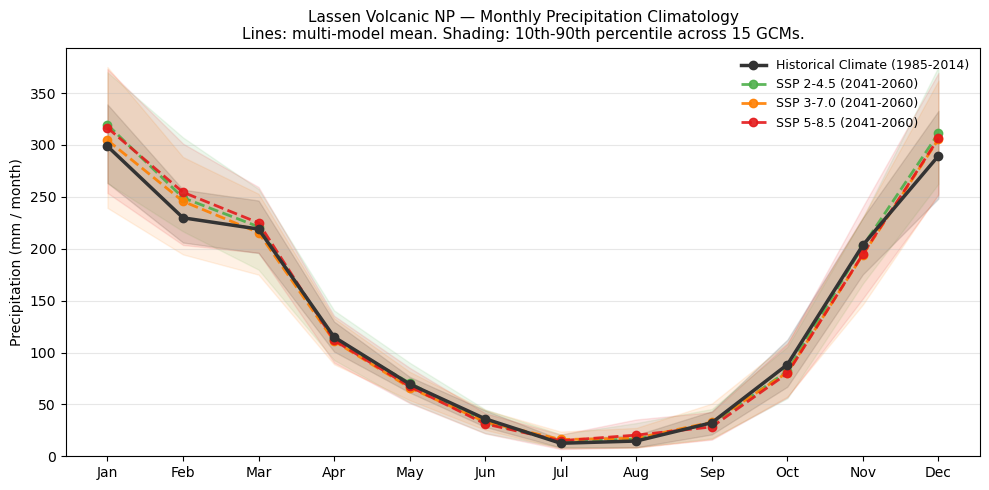

In [13]:
def monthly_climatology(da):
    """Per-month mean across years; returns (simulation, month) DataArray."""
    return da.groupby("time.month").mean("time")

clim_hist = monthly_climatology(hist_slice)
clim_future = {scen: monthly_climatology(s) for scen, s in future_slices.items()}

# MMEM + 10/90 spread across simulations
def mmem_and_spread(clim):
    mmem = clim.mean("simulation")
    spread = clim.quantile([0.1, 0.9], dim="simulation")
    return mmem, spread

mmem_hist, spread_hist = mmem_and_spread(clim_hist)
mmem_future = {s: mmem_and_spread(c) for s, c in clim_future.items()}

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
months = np.arange(1, 13)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Historical — solid line + shaded spread
ax.plot(months, mmem_hist.values, "-o", color=COLORS["Historical Climate"],
        linewidth=2.5, label=f"Historical Climate (1985-2014)", zorder=3)
ax.fill_between(months, spread_hist.sel(quantile=0.1).values,
                spread_hist.sel(quantile=0.9).values,
                color=COLORS["Historical Climate"], alpha=0.15)

# Futures — dashed lines
for scen in ["SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]:
    mmem, spread = mmem_future[scen]
    ax.plot(months, mmem.values, "--o", color=COLORS[scen], linewidth=2,
            label=f"{scen} (2041-2060)", alpha=0.9)
    ax.fill_between(months, spread.sel(quantile=0.1).values,
                    spread.sel(quantile=0.9).values,
                    color=COLORS[scen], alpha=0.10)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_ylabel("Precipitation (mm / month)")
ax.set_title("Lassen Volcanic NP — Monthly Precipitation Climatology\nLines: multi-model mean. Shading: 10th-90th percentile across 15 GCMs.",
             fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()

Northern Sierra seasonality is sharp: a pronounced Dec-Feb peak from Pacific storms, a ~5 mm/month bone-dry summer. The shaded bands show where the 15-GCM ensemble disagrees — wide in winter, tight in summer, which is expected (storm-track variability drives winter precip; summer is consistently dry by thermodynamic argument).

## 9. Annual-total trajectory (1950-2100)

One number per year: sum of 12 monthly values = annual total precip. The library's `annual_aggregate()` does exactly this (Precip → sum, Temperature → mean), and `smooth()` applies a centered rolling mean to pull out the forced signal from interannual noise.

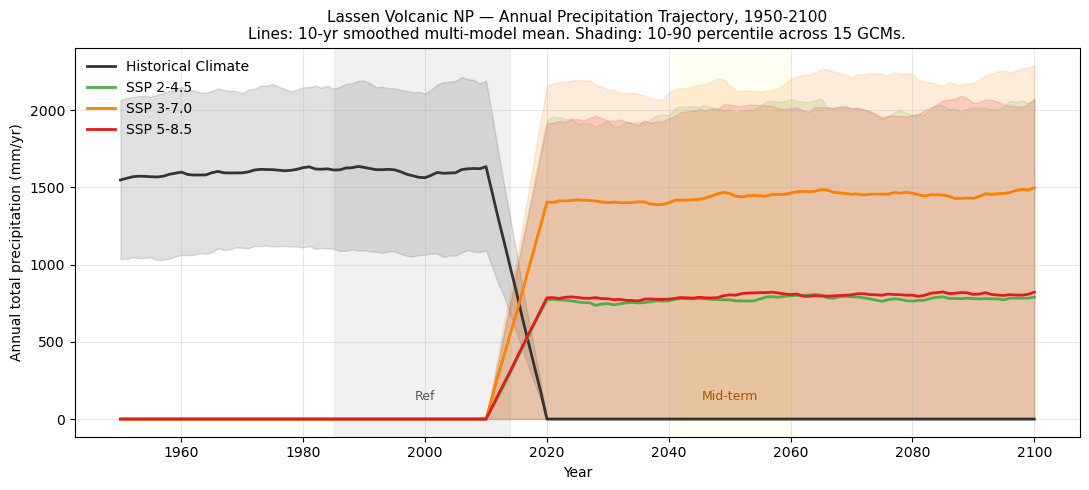

In [14]:
# Per scenario: annual total, ensemble mean + 10-90 spread, smoothed
fig, ax = plt.subplots(figsize=(11, 5))

for scen in scenarios:
    da = precip.sel(scenario=scen)
    annual = annual_aggregate(da, "Precip")      # library helper — per-simulation annual sums
    mmem = annual.mean("simulation")
    spread = annual.quantile([0.1, 0.9], dim="simulation")

    # Smooth to emphasize the forced signal
    mmem_smooth = smooth(mmem, window=10)
    spread_lo = smooth(spread.sel(quantile=0.1), window=10)
    spread_hi = smooth(spread.sel(quantile=0.9), window=10)

    years = pd.DatetimeIndex(mmem.time.values).year
    ax.plot(years, mmem_smooth.values, color=COLORS[scen], linewidth=2, label=scen)
    ax.fill_between(years, spread_lo.values, spread_hi.values,
                    color=COLORS[scen], alpha=0.15)

# Mark the reference and future windows
ax.axvspan(1985, 2014, color="lightgray", alpha=0.3, zorder=0)
ax.axvspan(2041, 2060, color="lightyellow", alpha=0.4, zorder=0)
ax.text(2000, ax.get_ylim()[1] * 0.05, "Ref", ha="center", fontsize=9, color="#555")
ax.text(2050, ax.get_ylim()[1] * 0.05, "Mid-term", ha="center", fontsize=9, color="#aa5500")

ax.set_xlabel("Year")
ax.set_ylabel("Annual total precipitation (mm/yr)")
ax.set_title("Lassen Volcanic NP — Annual Precipitation Trajectory, 1950-2100\n"
             "Lines: 10-yr smoothed multi-model mean. Shading: 10-90 percentile across 15 GCMs.",
             fontsize=11)
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()

This is the "when does it happen and how big does it get" view. Annual totals are noisy year-to-year (interannual variability from atmospheric-river count) so the 10-year smoothing is essential for seeing any trend. Divergence between SSPs really only becomes clear past ~2060; for mid-term planning (the yellow band), the signal is modest relative to the model spread.

## 10. Seasonal totals — meteorological DJF / MAM / JJA / SON

xarray's `.resample(time="QS-DEC")` produces quarterly totals starting in December — i.e., DJF straddles Dec(Y-1) + Jan(Y) + Feb(Y), which is the meteorological convention. No manual year-shifting.

In [15]:
# Annual seasonal totals per (scenario, simulation, season-year)
# QS-DEC = Quarter-Start, starting in December. Each resampled time label is the
# first day of the season (e.g., 1989-12-01 → DJF of water/meteorological year 1990).
seasonal = precip.resample(time="QS-DEC").sum(dim="time", skipna=True)

# Label each seasonal-year with its season name
season_names = seasonal["time"].dt.season    # "DJF" / "MAM" / "JJA" / "SON"
seasonal = seasonal.assign_coords(season=("time", season_names.values))

# Drop incomplete seasons at the endpoints (first DJF has no Dec 1949, etc.)
# A clean way: keep only full 3-month sums. Months-in-quarter from the resample
# gives us this implicitly — but xarray doesn't expose it, so filter by count instead.
months_in_quarter = precip.resample(time="QS-DEC").count(dim="time")
seasonal = seasonal.where(months_in_quarter == 3, drop=False)

print("Seasonal totals DataArray:")
print(seasonal)
print(f"\nUnique seasons: {np.unique(season_names.values)}")

Seasonal totals DataArray:
<xarray.DataArray 'Precip' (scenario: 4, simulation: 70, time: 605)> Size: 1MB
array([[[         nan, 537.96842515,  62.21955851, ...,          nan,
                  nan,          nan],
        [         nan, 179.75911186,   3.47356418, ...,          nan,
                  nan,          nan],
        [         nan, 213.75051491,  38.0113917 , ...,          nan,
                  nan,          nan],
        ...,
        [         nan, 211.91023334,  76.5313524 , ...,          nan,
                  nan,          nan],
        [         nan, 178.22677917,  26.69211009, ...,          nan,
                  nan,          nan],
        [         nan, 411.21772434,  79.90334246, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ...,  27.02081759,
         251.44441579,          nan],
        [         nan,          nan,          nan, ...,  42.021249  ,
         440.89029287,          nan],
        [      

In [16]:
# Per scenario: restrict to window, then take mean over years WITHIN each season
# Result: one 4-element series per scenario (DJF, MAM, JJA, SON)
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
SEASON_LABELS = {"DJF": "Winter (DJF)", "MAM": "Spring (MAM)",
                 "JJA": "Summer (JJA)", "SON": "Autumn (SON)"}

def seasonal_means_in_window(da_scen, window):
    """Mean seasonal total within a year-window; returns (simulation, season) DataArray."""
    windowed = da_scen.sel(time=slice(*window))
    return windowed.groupby("season").mean("time")

hist_seasonal = seasonal_means_in_window(
    seasonal.sel(scenario="Historical Climate"), HIST_WINDOW)
future_seasonal = {
    scen: seasonal_means_in_window(seasonal.sel(scenario=scen), FUTURE_WINDOW)
    for scen in scenarios if scen != "Historical Climate"
}

# Shape check: should be (simulation=15, season=4)
print(f"hist_seasonal.sizes: {dict(hist_seasonal.sizes)}")

hist_seasonal.sizes: {'simulation': 70, 'season': 4}


In [17]:
# MMEM + 10-90 spread for each (scenario × season)
def summarize(da):
    return pd.Series({
        "mmem":  float(da.mean("simulation")),
        "p10":   float(da.quantile(0.1, "simulation")),
        "p90":   float(da.quantile(0.9, "simulation")),
    })

rows = []
for season in SEASON_ORDER:
    rows.append(("Historical Climate", season, *summarize(hist_seasonal.sel(season=season))))
    for scen in scenarios:
        if scen == "Historical Climate": continue
        rows.append((scen, season, *summarize(future_seasonal[scen].sel(season=season))))

seasonal_summary = pd.DataFrame(
    rows, columns=["scenario", "season", "mmem", "p10", "p90"]
)
seasonal_summary_wide = seasonal_summary.pivot(
    index="scenario", columns="season", values="mmem"
)[SEASON_ORDER].reindex(scenarios)
seasonal_summary_wide.round(1)

season,DJF,MAM,JJA,SON
scenario,,,,
Historical Climate,817.7,403.5,63.3,324.3
SSP 2-4.5,874.7,404.4,63.5,316.0
SSP 3-7.0,861.7,392.7,66.7,307.8
SSP 5-8.5,878.9,403.9,66.6,303.0


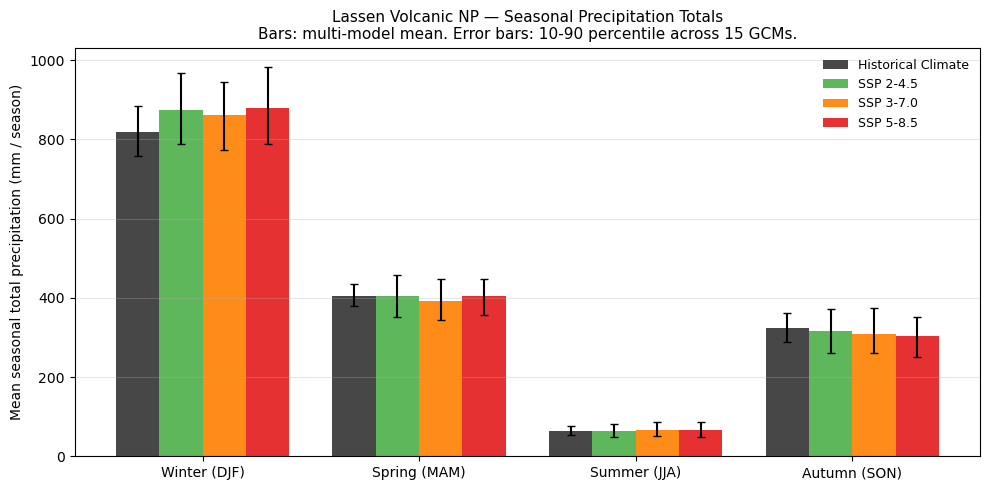

In [18]:
# Grouped bar chart with 10-90 error bars
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.2

for i, scen in enumerate(scenarios):
    mmem_vals = [
        seasonal_summary.query(f"scenario == @scen and season == @s").mmem.iloc[0]
        for s in SEASON_ORDER
    ]
    p10_vals = [
        seasonal_summary.query(f"scenario == @scen and season == @s").p10.iloc[0]
        for s in SEASON_ORDER
    ]
    p90_vals = [
        seasonal_summary.query(f"scenario == @scen and season == @s").p90.iloc[0]
        for s in SEASON_ORDER
    ]
    err_low  = [m - lo for m, lo in zip(mmem_vals, p10_vals)]
    err_high = [hi - m for m, hi in zip(mmem_vals, p90_vals)]

    ax.bar(x + (i - 1.5) * width, mmem_vals, width,
           yerr=[err_low, err_high], capsize=3,
           color=COLORS[scen], label=scen, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([SEASON_LABELS[s] for s in SEASON_ORDER])
ax.set_ylabel("Mean seasonal total precipitation (mm / season)")
ax.set_title("Lassen Volcanic NP — Seasonal Precipitation Totals\n"
             "Bars: multi-model mean. Error bars: 10-90 percentile across 15 GCMs.",
             fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()

## 11. So % change by season, with model agreement

For each season and SSP, we'llt ake % change from the historical MMEM using the IPCC convention:

$$\Delta = \frac{\text{MMEM}_{\text{future}} - \text{MMEM}_{\text{hist}}}{\text{MMEM}_{\text{hist}}} \times 100$$

Then, we'll end up counting how many of the 15 individual GCMs agree with the sign of the MMEM change. Higher agreement = more robust signal!

In [19]:
def pct_change_with_agreement(future_da, hist_da):
    """Returns (mmem_pct_change, n_agree, n_total) per season.

    mmem_pct_change uses (MMEM_future - MMEM_hist) / MMEM_hist × 100 — IPCC convention.
    n_agree counts GCMs whose individual pct change has the same sign as the MMEM.
    """
    mmem_fut = future_da.mean("simulation")
    mmem_hist = hist_da.mean("simulation")
    pct = (mmem_fut - mmem_hist) / mmem_hist * 100

    # Individual-model pct changes: align simulations across historical and future
    # (in LOCA2 historical and ssp use the same GCMs, so .sel works.)
    per_sim_pct = (future_da - mmem_hist) / mmem_hist * 100
    agree = (np.sign(per_sim_pct) == np.sign(pct)).sum("simulation")
    total = future_da.sizes["simulation"]
    return pct, agree, total

pct_rows = []
for scen in scenarios:
    if scen == "Historical Climate":
        continue
    pct, agree, total = pct_change_with_agreement(
        future_seasonal[scen], hist_seasonal
    )
    for season in SEASON_ORDER:
        pct_rows.append({
            "scenario": scen,
            "season": season,
            "pct_change": float(pct.sel(season=season)),
            "n_agree": int(agree.sel(season=season)),
            "n_total": total,
        })

pct_df = pd.DataFrame(pct_rows)
pct_df_display = pct_df.copy()
pct_df_display["pct_change"] = pct_df_display["pct_change"].round(1)
pct_df_display["agreement"] = pct_df_display.apply(
    lambda r: f"{r['n_agree']}/{r['n_total']}", axis=1
)
pct_df_display.pivot(index="scenario", columns="season",
                     values="pct_change")[SEASON_ORDER].reindex(
    [s for s in scenarios if s != "Historical Climate"])

season,DJF,MAM,JJA,SON
scenario,,,,
SSP 2-4.5,7.0,0.2,0.2,-2.5
SSP 3-7.0,5.4,-2.7,5.3,-5.1
SSP 5-8.5,7.5,0.1,5.1,-6.6


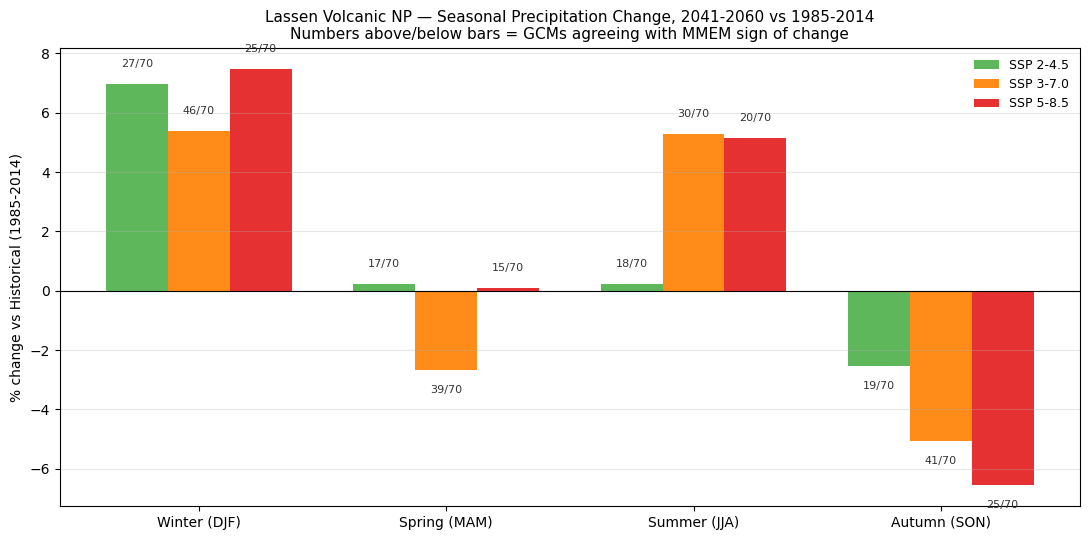

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(4)
width = 0.25
future_scens = [s for s in scenarios if s != "Historical Climate"]

for i, scen in enumerate(future_scens):
    sub = pct_df.query("scenario == @scen").set_index("season").reindex(SEASON_ORDER)
    bars = ax.bar(x + (i - 1) * width, sub["pct_change"], width,
                  color=COLORS[scen], label=scen, alpha=0.9)

    # Annotate each bar with agreement count (N/15)
    for bar, (_, row) in zip(bars, sub.iterrows()):
        h = bar.get_height()
        va = "bottom" if h >= 0 else "top"
        offset = 0.5 if h >= 0 else -0.5
        ax.text(bar.get_x() + bar.get_width() / 2, h + offset,
                f"{row['n_agree']}/{row['n_total']}",
                ha="center", va=va, fontsize=8, color="#333")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([SEASON_LABELS[s] for s in SEASON_ORDER])
ax.set_ylabel("% change vs Historical (1985-2014)")
ax.set_title("Lassen Volcanic NP — Seasonal Precipitation Change, 2041-2060 vs 1985-2014\n"
             "Numbers above/below bars = GCMs agreeing with MMEM sign of change",
             fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 12. Summary table

One-glance view: each cell shows MMEM % change plus the ensemble 10-90 range plus sign agreement.

In [21]:
# Build per-simulation % change DataArrays so we can summarise the spread per (scenario, season)
rows = []
for scen in future_scens:
    per_sim_pct = (future_seasonal[scen] - hist_seasonal.mean("simulation")) \
                  / hist_seasonal.mean("simulation") * 100
    mmem_pct = per_sim_pct.mean("simulation")
    p10 = per_sim_pct.quantile(0.1, "simulation")
    p90 = per_sim_pct.quantile(0.9, "simulation")
    agree = (np.sign(per_sim_pct) == np.sign(mmem_pct)).sum("simulation")

    for season in SEASON_ORDER:
        rows.append({
            "scenario": scen,
            "season": SEASON_LABELS[season],
            "MMEM Δ%": f"{float(mmem_pct.sel(season=season)):+.1f}",
            "10-90 range": f"[{float(p10.sel(season=season)):+.1f}, "
                           f"{float(p90.sel(season=season)):+.1f}]",
            "agreement": f"{int(agree.sel(season=season))}/{future_seasonal[scen].sizes['simulation']}",
        })
summary_table = pd.DataFrame(rows)
summary_table

,scenario,season,MMEM Δ%,10-90 range,agreement
0,SSP 2-4.5,Winter (DJF),+7.0,"[-3.7, +18.4]",27/70
1,SSP 2-4.5,Spring (MAM),+0.2,"[-12.7, +13.2]",17/70
2,SSP 2-4.5,Summer (JJA),+0.2,"[-23.2, +30.4]",18/70
3,SSP 2-4.5,Autumn (SON),-2.5,"[-19.5, +15.0]",19/70
4,SSP 3-7.0,Winter (DJF),+5.4,"[-5.6, +15.6]",46/70
5,SSP 3-7.0,Spring (MAM),-2.7,"[-15.0, +10.6]",39/70
6,SSP 3-7.0,Summer (JJA),+5.3,"[-20.8, +35.2]",30/70
7,SSP 3-7.0,Autumn (SON),-5.1,"[-19.5, +15.2]",41/70
8,SSP 5-8.5,Winter (DJF),+7.5,"[-3.7, +20.1]",25/70
9,SSP 5-8.5,Spring (MAM),+0.1,"[-11.9, +11.0]",15/70


## 13. Growth

I suppose a few things to consider are that:

- **Extremes.** A 20-year mean is a seasonal-climatology view. We don't get anything tells you nothing about atmospheric-river intensity, 99th-percentile daily precip, or drought duration — all of which also shift, also single events, which are quite important economically, as they can wipe outhomes and infastrucutre are largely balckboxed, though this is a problem for most climitaological modeling as of now. 
- **Internal variability.** 20-year windows still contain decadal noise. IPCC AR6 formally separates "forced signal" from "internal variability"; we show ensemble spread but don't explicitly decompose these sources of uncertainty.
- **Single park ≠ watershed.** Lassen Volcanic NP covers the upper North Fork Feather headwaters, not the whole 9,000 km² watershed. Middle Fork and South Fork Feather drain lower-elevation, os yeah more southerly terrain where the signal may differ.
- **Downscaling choice.** LOCA2 is statistical downscaling, which preserves GCM-level trends but can miss local dynamical features. WRF (dynamical) is also available via this library for the same region, but, we generally take LOCA2 to be more helpful (and the reason it isn't avaliable everywhere is from the extra overheap it takes to get such data.)

### Shutdown

In [22]:
cluster.close()
print("Done.")

Done.
